COMPETITORS CHECK AND UPDATION OF BASS PARAMETERS


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

pd.set_option("display.max_columns", None)

In [ ]:
competition_df = pd.read_csv("competition_data.csv")
bass_df = pd.read_csv("bass.csv")
similarity_df = pd.read_csv("similarity_analog.csv")
weekly_df = pd.read_csv("weekly_rx.csv")

print("Competition:", competition_df.shape)
print("Bass:", bass_df.shape)
print("Similarity:", similarity_df.shape)
print("Weekly Rx:", weekly_df.shape)

Competition: (533, 20)
Bass: (150, 11)
Similarity: (150, 13)
Weekly Rx: (7800, 4)


CHOOSE P001 AND IT HAD 4 COMPETITIORS

In [ ]:
PRODUCT_ID = "P001"

product_info = similarity_df[
    similarity_df["product_id"] == PRODUCT_ID
]

bass_info = bass_df[
    bass_df["product_id"] == PRODUCT_ID
]

rx_info = weekly_df[
    weekly_df["product_id"] == PRODUCT_ID
]

competitor_info = competition_df[
    competition_df["product_id"] == PRODUCT_ID
]

print("PRODUCT INFORMATION")
display(product_info)

print("\nBASS FEATURES")
display(bass_info)

print("\nCOMPETITORS")
display(competitor_info)

PRODUCT INFORMATION


,product_id,therapeutic_area,indication,active_ingredient,pharmacological_class,mechanism_of_action,route_of_administration,target_population,addressable_population,competition_level,relative_price_index,market_access_level,clinical_evidence_strength
0,P001,Oncology,Colorectal Cancer,Bevacizumab,VEGF Inhibitor (Monoclonal Antibody),"Inhibits VEGF, blocking tumor angiogenesis",Intravenous Infusion,Adult,230154,1.8,2.45,7.9,8.1



BASS FEATURES


,product_id,addressable_population,estimated_penetration,competition_level,market_access_level,relative_price_index,marketing_awareness,launch_strength,physician_awareness,clinical_evidence_strength,treatment_familiarity
0,P001,230154,0.204,1.8,7.9,2.45,5.1,4.3,6.7,8.1,5.6



COMPETITORS


,product_id,competitor_id,target_competitor_count,target_total_competitor_share,target_competition_level_proxy,therapeutic_similarity,competitor_market_share,relative_price_index,competitor_launch_gap_months,market_access_strength,clinical_evidence_strength,brand_strength,brand_generic_flag,competitor_growth_rate,promotion_intensity,payer_access_friction,substitutability_proxy,data_origin,source_basis,synthetic_flag
0,P001,C0001,4,0.266,Medium,0.815,0.038,1.024,-36,Medium,Medium,High,Brand,-0.062,0.773,0.061,0.594,Source-informed synthetic,FDA/openFDA; FDA Orange Book; CMS Part D; IQVI...,1
1,P001,C0002,4,0.266,Medium,0.533,0.138,0.450,-33,Medium,Medium,High,Brand,0.199,0.685,0.102,0.313,Source-informed synthetic,FDA/openFDA; FDA Orange Book; CMS Part D; IQVI...,1
2,P001,C0003,4,0.266,Medium,0.669,0.058,1.110,-24,Medium,Medium,Low,Generic,0.407,0.270,0.729,0.593,Source-informed synthetic,FDA/openFDA; FDA Orange Book; CMS Part D; IQVI...,1
3,P001,C0004,4,0.266,Medium,0.824,0.031,1.128,36,High,Medium,Medium,Brand,0.213,0.340,0.453,0.508,Source-informed synthetic,FDA/openFDA; FDA Orange Book; CMS Part D; IQVI...,1


In [ ]:
weekly_df = weekly_df.sort_values(
    ["product_id", "week_since_launch"]
).copy()

weekly_df["cumulative_rx_original"] = weekly_df["cumulative_rx"]

weekly_df["cumulative_rx"] = (
    weekly_df.groupby("product_id")["weekly_rx"]
             .cumsum()
)

In [ ]:
weekly_df["cumulative_error"] = (
    weekly_df["cumulative_rx_original"]
    - weekly_df["cumulative_rx"]
)

print(
    weekly_df["cumulative_error"]
    .abs()
    .describe()
)

count    7800.000000
mean        1.106154
std         1.093764
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: cumulative_error, dtype: float64


In [ ]:
display(
    weekly_df[
        weekly_df["product_id"] == "P001"
    ].head(10)
)

,product_id,week_since_launch,weekly_rx,cumulative_rx,cumulative_rx_original,cumulative_error
0,P001,1,1034,1034,1034,0
1,P001,2,1118,2152,2152,0
2,P001,3,1418,3570,3571,1
3,P001,4,1628,5198,5198,0
4,P001,5,1591,6789,6789,0
5,P001,6,1863,8652,8652,0
6,P001,7,2167,10819,10819,0
7,P001,8,1732,12551,12551,0
8,P001,9,2252,14803,14803,0
9,P001,10,1958,16761,16761,0


LAUNCH CURVE

In [ ]:
product_rx = weekly_df[
    weekly_df["product_id"] == PRODUCT_ID
].copy()

weeks = product_rx["week_since_launch"].values

actual_cumulative = product_rx["cumulative_rx"].values

print("Weeks:", len(product_rx))
print("Final cumulative Rx:", actual_cumulative[-1])

Weeks: 52
Final cumulative Rx: 46234


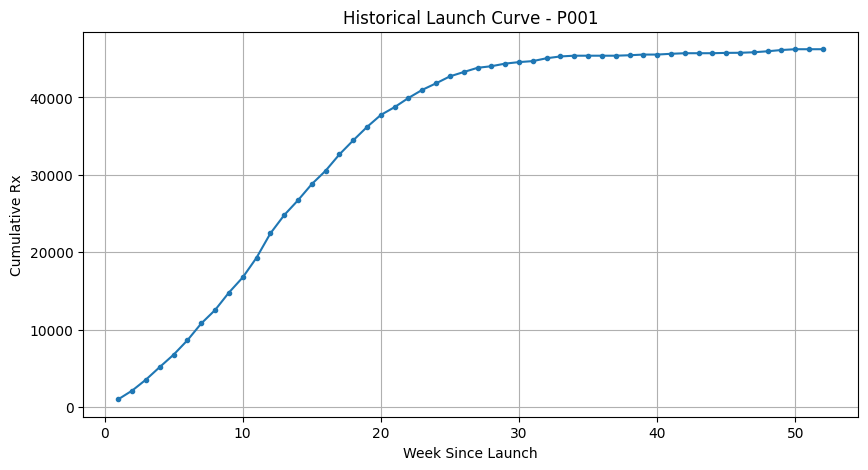

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    weeks,
    actual_cumulative,
    marker="o",
    markersize=3
)

plt.xlabel("Week Since Launch")
plt.ylabel("Cumulative Rx")
plt.title(f"Historical Launch Curve - {PRODUCT_ID}")
plt.grid(True)

plt.show()

In [ ]:
def bass_cumulative(t, p, q, m):
    """
    Bass cumulative adoption model.

    p = innovation coefficient
    q = imitation coefficient
    m = total market potential
    """

    exp_term = np.exp(-(p + q) * t)

    return m * (
        (1 - exp_term) /
        (1 + (q / p) * exp_term)
    )

In [ ]:
initial_p = 0.01
initial_q = 0.1
initial_m = actual_cumulative[-1] * 1.5

initial_guess = [
    initial_p,
    initial_q,
    initial_m
]

In [ ]:
params, covariance = curve_fit(
    bass_cumulative,
    weeks,
    actual_cumulative,
    p0=initial_guess,
    bounds=(
        [0.00001, 0.00001, actual_cumulative[-1]],
        [1.0, 1.0, actual_cumulative[-1] * 20]
    ),
    maxfev=50000
)

p_base, q_base, m_base = params

print("BASE BASS PARAMETERS")
print("--------------------")
print("p =", round(p_base, 6))
print("q =", round(q_base, 6))
print("m =", round(m_base, 2))

BASE BASS PARAMETERS
--------------------
p = 0.020699
q = 0.163128
m = 46234.0


FORECAST (BASELINE)

In [ ]:
baseline_forecast = bass_cumulative(
    weeks,
    p_base,
    q_base,
    m_base
)

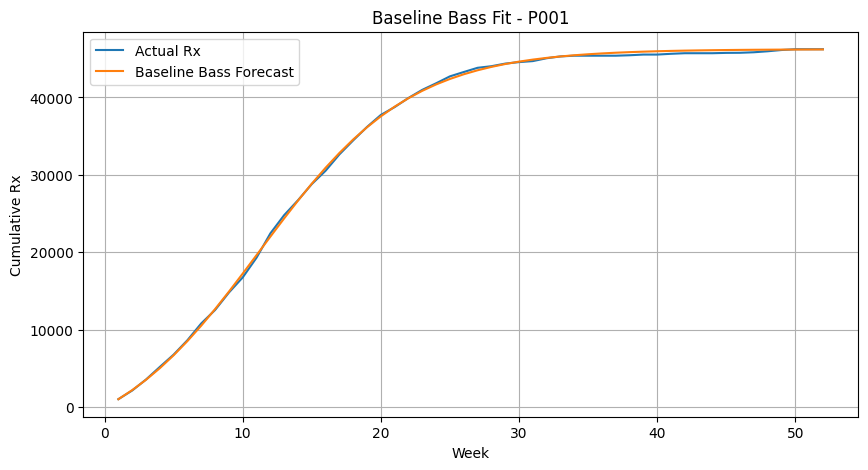

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    weeks,
    actual_cumulative,
    label="Actual Rx"
)

plt.plot(
    weeks,
    baseline_forecast,
    label="Baseline Bass Forecast"
)

plt.xlabel("Week")
plt.ylabel("Cumulative Rx")
plt.title(f"Baseline Bass Fit - {PRODUCT_ID}")
plt.legend()
plt.grid(True)

plt.show()

COMPETITORS


In [ ]:
comp = competition_df[
    competition_df["product_id"] == PRODUCT_ID
].copy()

display(
    comp[
        [
            "competitor_id",
            "competitor_market_share",
            "therapeutic_similarity",
            "relative_price_index",
            "market_access_strength",
            "clinical_evidence_strength",
            "brand_strength",
            "competitor_growth_rate"
        ]
    ]
)

,competitor_id,competitor_market_share,therapeutic_similarity,relative_price_index,market_access_strength,clinical_evidence_strength,brand_strength,competitor_growth_rate
0,C0001,0.038,0.815,1.024,Medium,Medium,High,-0.062
1,C0002,0.138,0.533,0.450,Medium,Medium,High,0.199
2,C0003,0.058,0.669,1.110,Medium,Medium,Low,0.407
3,C0004,0.031,0.824,1.128,High,Medium,Medium,0.213


In [ ]:
level_mapping = {
    "Low": 0.25,
    "Medium": 0.50,
    "High": 0.75
}

comp["market_access_score"] = (
    comp["market_access_strength"]
    .map(level_mapping)
)

comp["clinical_score"] = (
    comp["clinical_evidence_strength"]
    .map(level_mapping)
)

comp["brand_score"] = (
    comp["brand_strength"]
    .map(level_mapping)
)

In [ ]:
comp["competitor_price_advantage"] = (
    1 - comp["relative_price_index"]
).clip(lower=0, upper=1)

In [ ]:
MIN_GROWTH = -0.25
MAX_GROWTH = 0.55

comp["growth_score"] = (
    (
        comp["competitor_growth_rate"]
        - MIN_GROWTH
    )
    /
    (MAX_GROWTH - MIN_GROWTH)
).clip(0, 1)

In [ ]:
comp["competitor_strength"] = (
    0.30 * comp["competitor_market_share"]
    +
    0.20 * comp["therapeutic_similarity"]
    +
    0.15 * comp["competitor_price_advantage"]
    +
    0.15 * comp["market_access_score"]
    +
    0.10 * comp["clinical_score"]
    +
    0.10 * comp["growth_score"]
)

In [ ]:
display(
    comp[
        [
            "competitor_id",
            "competitor_market_share",
            "therapeutic_similarity",
            "competitor_price_advantage",
            "market_access_score",
            "clinical_score",
            "growth_score",
            "competitor_strength"
        ]
    ].sort_values(
        "competitor_strength",
        ascending=False
    )
)

,competitor_id,competitor_market_share,therapeutic_similarity,competitor_price_advantage,market_access_score,clinical_score,growth_score,competitor_strength
1,C0002,0.138,0.533,0.55,0.50,0.5,0.56125,0.411625
3,C0004,0.031,0.824,0.00,0.75,0.5,0.57875,0.394475
2,C0003,0.058,0.669,0.00,0.50,0.5,0.82125,0.358325
0,C0001,0.038,0.815,0.00,0.50,0.5,0.23500,0.322900


In [ ]:
competitor_count = len(comp)

total_market_share = min(
    comp["competitor_market_share"].sum(),
    1
)

avg_strength = comp["competitor_strength"].mean()

max_strength = comp["competitor_strength"].max()

avg_similarity = comp["therapeutic_similarity"].mean()

print("Number of competitors:", competitor_count)
print("Total competitor share:", round(total_market_share, 3))
print("Average competitor strength:", round(avg_strength, 3))
print("Strongest competitor:", round(max_strength, 3))
print("Average similarity:", round(avg_similarity, 3))

Number of competitors: 4
Total competitor share: 0.265
Average competitor strength: 0.372
Strongest competitor: 0.412
Average similarity: 0.71


In [ ]:
competition_index = (
    0.35 * total_market_share
    +
    0.30 * avg_strength
    +
    0.20 * max_strength
    +
    0.15 * avg_similarity
)

competition_index = np.clip(
    competition_index,
    0,
    1
)

print(
    "Market Competition Index:",
    round(competition_index, 3)
)

Market Competition Index: 0.393


In [ ]:
def competition_category(score):

    if score < 0.25:
        return "Low"

    elif score < 0.50:
        return "Moderate"

    elif score < 0.75:
        return "High"

    else:
        return "Very High"


competition_level = competition_category(
    competition_index
)

print(
    "Competition Level:",
    competition_level
)

Competition Level: Moderate


TARGET PRODUCT ADVANTAGE

In [ ]:
target = bass_df[
    bass_df["product_id"] == PRODUCT_ID
].iloc[0]

target_access = target["market_access_level"] / 10
target_clinical = target["clinical_evidence_strength"] / 10
target_launch = target["launch_strength"] / 10
target_physician_awareness = target["physician_awareness"] / 10

print("Market Access:", target_access)
print("Clinical Evidence:", target_clinical)
print("Launch Strength:", target_launch)
print("Physician Awareness:", target_physician_awareness)

Market Access: 0.79
Clinical Evidence: 0.8099999999999999
Launch Strength: 0.43
Physician Awareness: 0.67


In [ ]:
comp["target_price_advantage"] = (
    comp["relative_price_index"] - 1
).clip(lower=0, upper=1)

target_price_advantage = (
    comp["target_price_advantage"].mean()
)

print(
    "Target Price Advantage:",
    round(target_price_advantage, 3)
)

Target Price Advantage: 0.066


In [ ]:
competitive_advantage = (
    0.30 * target_access
    +
    0.30 * target_clinical
    +
    0.20 * target_launch
    +
    0.10 * target_physician_awareness
    +
    0.10 * target_price_advantage
)

competitive_advantage = np.clip(
    competitive_advantage,
    0,
    1
)

print(
    "Target Competitive Advantage:",
    round(competitive_advantage, 3)
)

Target Competitive Advantage: 0.64


In [ ]:
net_competition_effect = (
    competition_index
    *
    (
        1
        - 0.50 * competitive_advantage
    )
)

net_competition_effect = np.clip(
    net_competition_effect,
    0,
    1
)

print(
    "Market Competition:",
    round(competition_index, 3)
)

print(
    "Target Advantage:",
    round(competitive_advantage, 3)
)

print(
    "Net Competition Effect:",
    round(net_competition_effect, 3)
)

Market Competition: 0.393
Target Advantage: 0.64
Net Competition Effect: 0.267


EFFECT ON BASS QUANTS


In [ ]:
ALPHA = 0.30   # effect on m
BETA = 0.15    # effect on p
GAMMA = 0.20   # effect on q


m_adjusted = (
    m_base *
    (1 - ALPHA * net_competition_effect)
)

p_adjusted = (
    p_base *
    (1 - BETA * net_competition_effect)
)

q_adjusted = (
    q_base *
    (1 - GAMMA * net_competition_effect)
)

In [ ]:
print("BASE PARAMETERS")
print("----------------")
print("p:", round(p_base, 6))
print("q:", round(q_base, 6))
print("m:", round(m_base, 2))


print("\nCOMPETITION ADJUSTED")
print("--------------------")
print("p:", round(p_adjusted, 6))
print("q:", round(q_adjusted, 6))
print("m:", round(m_adjusted, 2))

BASE PARAMETERS
----------------
p: 0.020699
q: 0.163128
m: 46234.0

COMPETITION ADJUSTED
--------------------
p: 0.019869
q: 0.154402
m: 42524.57


ADJUSTED FORECAST

In [ ]:
competition_forecast = bass_cumulative(
    weeks,
    p_adjusted,
    q_adjusted,
    m_adjusted
)

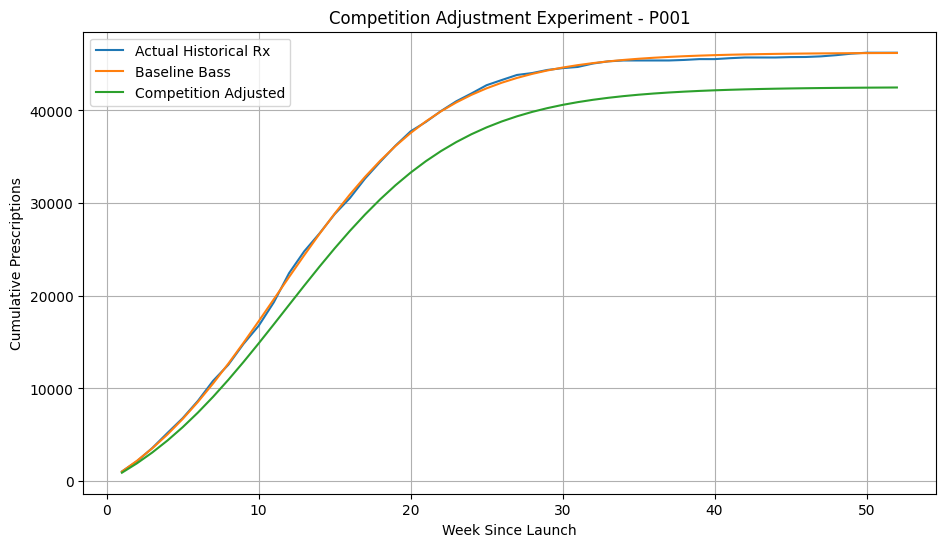

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(
    weeks,
    actual_cumulative,
    label="Actual Historical Rx"
)

plt.plot(
    weeks,
    baseline_forecast,
    label="Baseline Bass"
)

plt.plot(
    weeks,
    competition_forecast,
    label="Competition Adjusted"
)

plt.xlabel("Week Since Launch")
plt.ylabel("Cumulative Prescriptions")

plt.title(
    f"Competition Adjustment Experiment - {PRODUCT_ID}"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
baseline_final = baseline_forecast[-1]
adjusted_final = competition_forecast[-1]

forecast_change = (
    (
        adjusted_final
        - baseline_final
    )
    /
    baseline_final
) * 100


print("=" * 50)
print("COMPETITION ADJUSTMENT RESULT")
print("=" * 50)

print("Product:", PRODUCT_ID)

print(
    "Competition Index:",
    round(competition_index, 3)
)

print(
    "Competition Level:",
    competition_level
)

print(
    "Competitive Advantage:",
    round(competitive_advantage, 3)
)

print(
    "Net Competition Effect:",
    round(net_competition_effect, 3)
)

print()

print(
    "Baseline Week-52 Forecast:",
    round(baseline_final)
)

print(
    "Adjusted Week-52 Forecast:",
    round(adjusted_final)
)

print(
    "Forecast Change:",
    round(forecast_change, 2),
    "%"
)

COMPETITION ADJUSTMENT RESULT
Product: P001
Competition Index: 0.393
Competition Level: Moderate
Competitive Advantage: 0.64
Net Competition Effect: 0.267

Baseline Week-52 Forecast: 46205
Adjusted Week-52 Forecast: 42481
Forecast Change: -8.06 %


In [ ]:
strongest_competitor = (
    comp.sort_values(
        "competitor_strength",
        ascending=False
    )
    .iloc[0]
)

print(
    "Strongest competitor:",
    strongest_competitor["competitor_id"]
)

print(
    "Strength:",
    round(
        strongest_competitor["competitor_strength"],
        3
    )
)

print(
    "Market Share:",
    strongest_competitor["competitor_market_share"]
)

print(
    "Therapeutic Similarity:",
    strongest_competitor["therapeutic_similarity"]
)

Strongest competitor: C0002
Strength: 0.412
Market Share: 0.138
Therapeutic Similarity: 0.533
